# Wall-Clock Analysis of Sequential Pi-Backdoor Adjustment

In [1]:
import random
import copy
import time
import torch
import pickle
import os
import matplotlib.pyplot as plt

from collections import defaultdict

from causal_gym import HumanoidMazePCH
from causal_rl.algo.imitation.imitate import *
from causal_rl.algo.imitation.finetune import *
from causal_rl.algo.imitation.gail.core_net import *
from causal_rl.algo.imitation.gail.causal_gail import *

<frozen importlib._bootstrap>:241: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
/home/et2842/miniconda3/envs/causalenv/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
num_steps = 2000
seed = 0
hidden_dims = {'O'}

random.seed(seed)
torch.manual_seed(seed)

In [3]:
# for training: regular W, O hidden
train_env = HumanoidMazePCH(env_id='humanoidmaze-large-navigate-singletask-task1-v0', num_steps=num_steps, expert_mode=True, custom_hidden=hidden_dims, seed=seed)

# for eval: corrupted W, O hidden
eval_env = HumanoidMazePCH(env_id='humanoidmaze-large-navigate-singletask-task1-v0', num_steps=num_steps, expert_mode=False, seed=seed)

## Causal Graph Analysis

In [4]:
lookback_values = [1, 10, 50, 100, 200, 500, 1000, 2000]
runtimes = {}

for lookback in lookback_values:
    t0 = time.time()

    # to save time; conceptually the same
    small_steps = lookback + 1
    small_env = HumanoidMazePCH(env_id='humanoidmaze-large-navigate-singletask-task1-v0', num_steps=small_steps, seed=seed)
    G = parse_graph(small_env.get_graph)
    X_small = {f'X{t}' for t in range(small_steps)}
    Y = f'Y{small_steps}'

    X = {f'X{t}' for t in range(num_steps)}
    obs_prefix = train_env.env.observed_unobserved_vars[0]

    Z_sets = find_sequential_pi_backdoor(G, X_small, Y, obs_prefix)

    base_step = small_steps - 1
    base_Z_set = Z_sets[f'X{base_step}']

    for i in range(base_step + 1, num_steps):
        updated_base_Z_set = set()
        for v in base_Z_set:
            updated_base_Z_set.add(f'{v[0]}{int(v[1:]) + i - lookback}')
        Z_sets[f'X{i}'] = updated_base_Z_set

    _ = Z_sets['X1']

    runtimes[lookback] = time.time() - t0
    print(f'lookback={lookback:>4d}: {runtimes[lookback]:.3f}s')

runtimes

lookback=   1: 7.080s


lookback=  10: 7.105s


lookback=  50: 7.640s


lookback= 100: 9.986s


lookback= 200: 24.528s


lookback= 500: 255.817s


lookback=1000: 1930.978s


lookback=2000: 14853.568s


{1: 7.07990837097168,
 10: 7.104868412017822,
 50: 7.640169143676758,
 100: 9.985640287399292,
 200: 24.528498888015747,
 500: 255.81743359565735,
 1000: 1930.9784903526306,
 2000: 14853.568275928497}

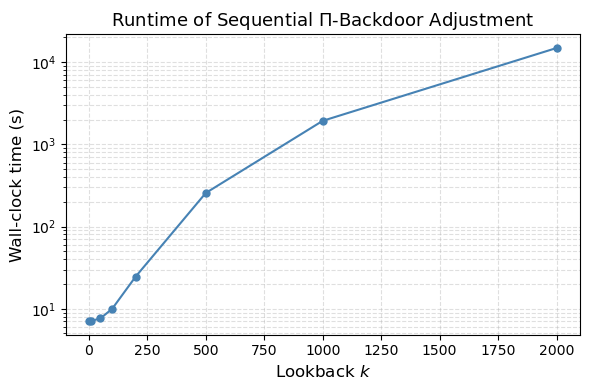

In [5]:
xs = list(runtimes.keys())
ys = list(runtimes.values())

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(xs, ys, 'o-', color='steelblue', linewidth=1.5, markersize=5)
ax.set_xlabel('Lookback $k$', fontsize=12)
ax.set_ylabel('Wall-clock time (s)', fontsize=12)
ax.set_title('Runtime of Sequential $\\Pi$-Backdoor Adjustment', fontsize=13)
ax.set_yscale('log')
ax.grid(True, which='both', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('wallclock.png', dpi=150)
plt.show()